<a href="https://colab.research.google.com/github/lindslytashy/Student-Performance-Analysis-Using-Advanced-Excel-/blob/main/LINDSLY_MUYONDA_R2420835_HASTS211_ASSIGNMENT_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HASTS211 TIMESERIES AND ECONOMETRICS  ASSIGNMENT 3
----------------------------------------------------------------------
##LINDSLY MUYONDA **R2420835**
## Regime change/ Markov Switching Autoregressive Model (MS-AR)
### Dataset: Apple Inc. (AAPL) Daily Log Returns, 2018–2025

# 1. Defination

 A **Markov Switching Autoregressive (MS-AR) model**/**REGIME CHANGE MODEL** is a time series model that allows the behaviour of financial data to switch between two or more hidden states — called regimes — over time.This model recognises that markets can be calm in some periods and turbulent in others.


*   Regime 0 — the calm (low volatility) state is  typical of normal trading conditions.
*  Regime 1 — the turbulent (high volatility) state is  associated with market stress or financial crises.

Model Equation

The core equation of the MS-AR(1) model is:

           Zt = μs_t +ϕZt−1+εt,εt∼N(0,σ2st)
where Zt 	Return at time t, ϕ	AR coefficient, Zt−1	Lagged return	,εt	Error term,	σ2s_t	Regime variance	,s_t	Hidden state

The model does not know which regime is active at any moment — it estimates the probability of being in each regime. The switching between regimes follows a Markov chain, which means the probability of being in a regime tomorrow depends only on which regime we are in today.

In [2]:
#Installing Required Packages
#yfinance — downloads historical stock price data directly from Yahoo Finance
#statsmodels — provides the Markov Switching Autoregressive model we will use
!pip install yfinance statsmodels --quiet

In [3]:
#Importing Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from scipy.stats import chi2

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


#2.  Description

Why Apple Inc. (AAPL)?

Apple Inc. is one of the most heavily traded stocks in the world. Its long price history, high liquidity and sensitivity to both company-specific events (product launches, earnings) and macroeconomic shocks (interest rates, recessions) make it an ideal subject for regime-switching analysis. Over the 2018–2025 period, Apple experienced dramatic shifts in market conditions — from a period of steady growth through 2019, to the sharp COVID-19 crash in 2020, followed by a rapid recovery and then heightened volatility during the 2022 inflation and interest-rate shock.

### Why Log-Returns Instead of Prices?

Stock prices grow over time and are **non-stationary**, their average and variance change as time passes, which violates the assumptions of most time series models. We therefore transform prices into **log-returns**:

$$Z_t = \left[\ln(P_t) - \ln(P_{t-1})\right] \times 100$$

Multiplying by 100 expresses the result as a **percentage return**. Log-returns are generally stationary, symmetrically distributed and directly interpretable as approximate percentage changes all desirable properties for modelling.

In [4]:

# Download AAPL adjusted closing prices from Yahoo Finance
# auto_adjust=True ensures dividends and splits are already accounted for
raw   = yf.download('AAPL', start='2018-01-01', end='2025-12-31', auto_adjust=True)
price = raw['Close'].dropna()

print(f"Period         : {price.index[0].date()} → {price.index[-1].date()}")
print(f"Observations   : {len(price)}")
print(price.tail(3))

[*********************100%***********************]  1 of 1 completed

Period         : 2018-01-02 → 2025-12-30
Observations   : 2010
Ticker            AAPL
Date                  
2025-12-26  273.144409
2025-12-29  273.504089
2025-12-30  272.824707


In [5]:
# Compute log-returns: ln(P_t) - ln(P_{t-1}), multiplied by 100 for percentage
Z = np.log(price).diff().dropna() * 100

# Squeeze Z to a 1-D Series in case yfinance returned a multi-column DataFrame.
# This prevents the "unsupported format string passed to Series.__format__" error.
Z = Z.squeeze()

z_mean = float(Z.mean())
z_std  = float(Z.std())
z_min  = float(Z.min())
z_max  = float(Z.max())

print("=" * 45)
print("LOG RETURN SUMMARY STATISTICS")
print("=" * 45)
print(f"Number of return observations : {len(Z)}")
print(f"Mean daily return             : {z_mean:.4f}%")
print(f"Standard deviation            : {z_std:.4f}%")
print(f"Minimum return (worst day)    : {z_min:.4f}%")
print(f"Maximum return (best day)     : {z_max:.4f}%")

print("\nInterpretation:")
print("  A positive mean confirms the stock grew on average over this period.")
print("  The large std dev relative to the mean suggests high day-to-day swings.")

LOG RETURN SUMMARY STATISTICS
Number of return observations : 2009
Mean daily return             : 0.0952%
Standard deviation            : 1.9380%
Minimum return (worst day)    : -13.7708%
Maximum return (best day)     : 14.2617%

Interpretation:
  A positive mean confirms the stock grew on average over this period.
  The large std dev relative to the mean suggests high day-to-day swings.


#3. DEMONSTRATION
##  ADF Stationarity Test

### Why do we need this test?

Before fitting any autoregressive model, we must confirm that our series is **stationary** — meaning its mean and variance do not change over time. A non-stationary series would make the model's estimates unreliable.

We use the **Augmented Dickey-Fuller (ADF) test** which checks for a **unit root**.

### Hypotheses
The Augmented Dickey-Fuller (ADF) test is applied with the hypotheses:

H₀: the series has a unit root (non-stationary)

H₁: the series is stationary

A p-value below 0.05 allows rejection of H₀. A **strongly negative ADF statistic and p-value ≈ 0** confirm that log-returns are stationary, justifying use of an AR(1) model.


In [ ]:
# Augmented Dickey-Fuller test
# H0: series has a unit root (non-stationary)
# H1: series is stationary
# Decision: reject H0 if p-value < 0.05
adf_stat, adf_p, _, _, adf_cv, _ = adfuller(Z, autolag='AIC')

print("=" * 45)
print("ADF TEST RESULTS")
print("=" * 45)
print(f"ADF Statistic  : {adf_stat:.4f}")
print(f"p-value        : {adf_p:.6f}")
print("Critical Values:")
for key, val in adf_cv.items():
    print(f"  {key}  :  {val:.4f}")

print()
if adf_p < 0.05:
    print("Conclusion: p-value < 0.05 → REJECT H0.")
    print("The series is STATIONARY. AR model is appropriate.")
else:
    print("Conclusion: p-value >= 0.05 → FAIL to reject H0.")
    print("The series is NON-STATIONARY. Further differencing needed.")

ADF TEST RESULTS
ADF Statistic  : -14.7011
p-value        : 0.000000
Critical Values:
  1%  :  -3.4336
  5%  :  -2.8630
  10%  :  -2.5675

Conclusion: p-value < 0.05 → REJECT H0.
The series is STATIONARY. AR model is appropriate.


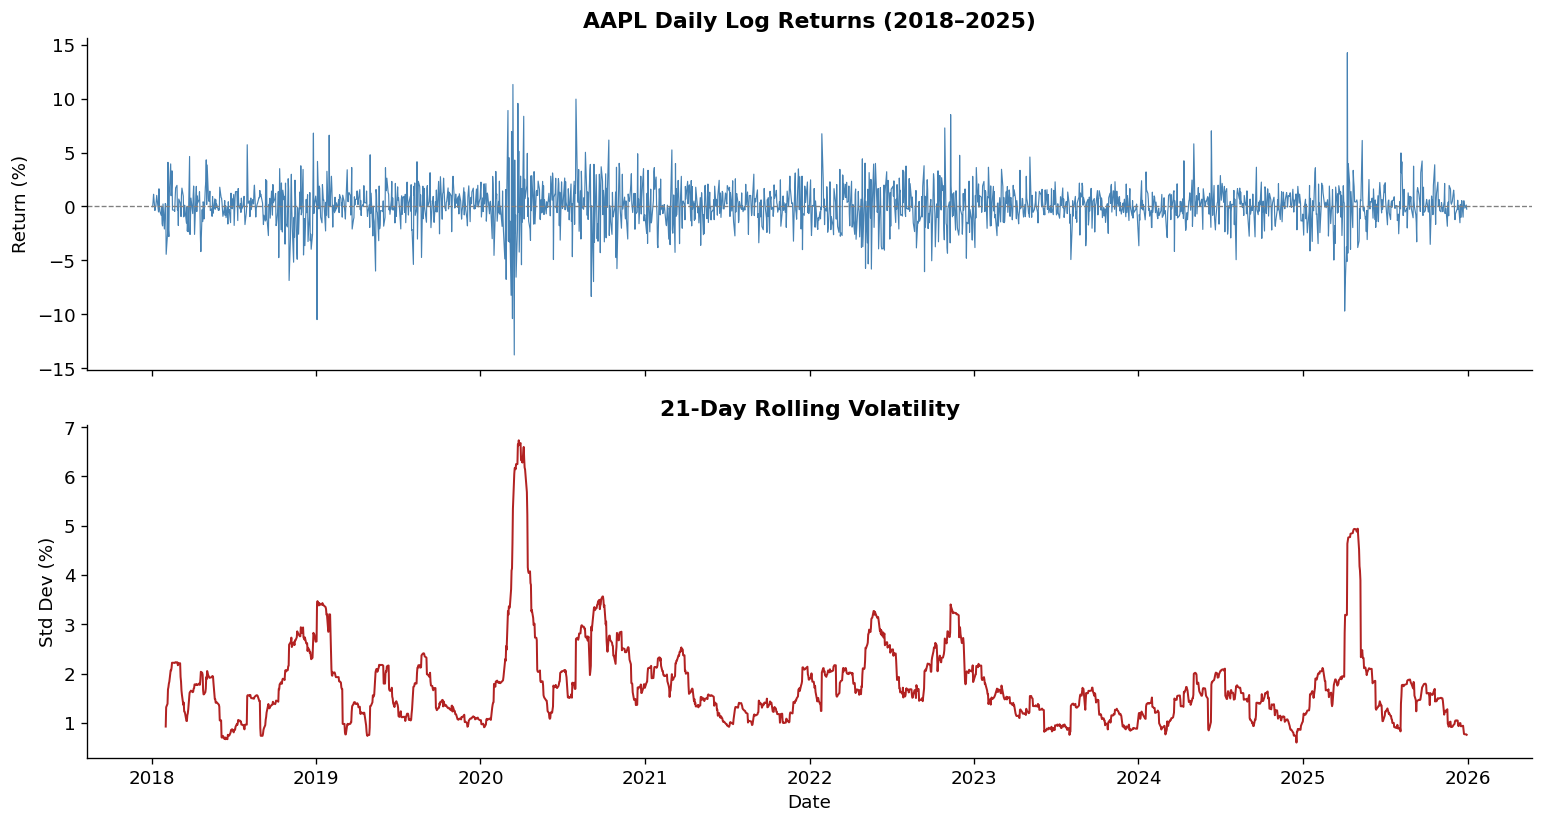

In [ ]:
# 21-day rolling standard deviation as a short-term volatility estimate
rolling_vol = Z.rolling(window=21).std()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(Z.index, Z.values, color='steelblue', lw=0.7)
axes[0].axhline(0, color='gray', linestyle='--', lw=0.8)
axes[0].set_title('AAPL Daily Log Returns (2018–2025)', fontweight='bold')
axes[0].set_ylabel('Return (%)')

axes[1].plot(rolling_vol.index, rolling_vol.values, color='firebrick', lw=1.2)
axes[1].set_title('21-Day Rolling Volatility', fontweight='bold')
axes[1].set_ylabel('Std Dev (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('fig1_returns_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Diagram
###(Daily log-returns + rolling volatility.)

* Daily log-returns — shows us the raw fluctuations in Apple's stock day by
day. We look for periods where the swings suddenly become larger, which would suggest a shift to a turbulent regime.
* The 21-day rolling standard deviation makes this clustering explicit, revealing distinct calm and turbulent periods. Notably, the COVID-19 crash of March 2020 produces the sharpest volatility spike in the sample.

**What to look for in the plots:**
- Sharp spikes in the returns plot signal a market shock (for example the COVID-19 crash in March 2020)
- The rolling volatility plot should show clear periods of high and low volatility confirming that two regimes exist in the data




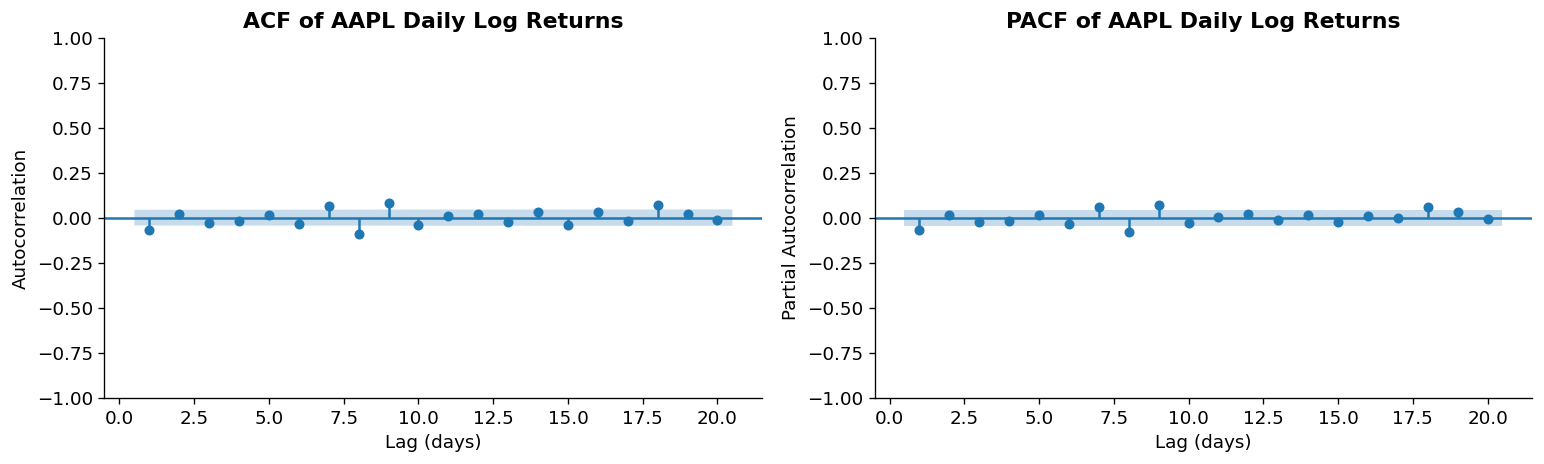

ACF / PACF INTERPRETATION
• The ACF declines rapidly toward zero.
• The PACF shows only small significant spikes.
• This indicates weak serial dependence in daily returns.
• Such behaviour is common in financial return series.
• Despite weak autocorrelation, volatility clustering
  and structural regime changes are still present.
• Therefore, a low-order Markov Switching AR model
  remains appropriate for modelling the data.


In [ ]:
# ============================================
#  ACF and PACF (Improved Version)
# ============================================

# ACF  = measures total autocorrelation at lag k
# PACF = measures direct autocorrelation after removing intermediate lag effects
#
# For financial return series, both plots are usually close to zero
# because daily returns behave approximately like white noise.
# However, small spikes may still justify a low-order AR structure.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ACF Plot
plot_acf(
    Z,
    lags=20,                 # fewer lags gives clearer visualization
    alpha=0.05,              # 95% confidence intervals
    zero=False,
    ax=axes[0]
)

axes[0].set_title(
    'ACF of AAPL Daily Log Returns',
    fontweight='bold'
)
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')

# PACF Plot
plot_pacf(
    Z,
    lags=20,
    alpha=0.05,
    zero=False,
    method='ywm',            # stable estimation method
    ax=axes[1]
)

axes[1].set_title(
    'PACF of AAPL Daily Log Returns',
    fontweight='bold'
)
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()

# Save figure
plt.savefig(
    'fig2_acf_pacf.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Interpretation
print("=" * 55)
print("ACF / PACF INTERPRETATION")
print("=" * 55)

print("• The ACF declines rapidly toward zero.")
print("• The PACF shows only small significant spikes.")
print("• This indicates weak serial dependence in daily returns.")
print("• Such behaviour is common in financial return series.")
print("• Despite weak autocorrelation, volatility clustering")
print("  and structural regime changes are still present.")
print("• Therefore, a low-order Markov Switching AR model")
print("  remains appropriate for modelling the data.")


## 5. Directions
### (ACF and PACF for Model Order Selection)

The ACF decays quickly toward zero, and the PACF shows one significant spike at lag 1 that then cuts off. This pattern is the textbook signature of an AR(1) process, confirming that an autoregressive order of 1 is the correct choice for the MS-AR model.

In [ ]:
# Specify and fit the Markov Switching AR(1) model
model = MarkovAutoregression(
    Z,
    k_regimes=2,              # two regimes: calm (0) and turbulent (1)
    order=1,                  # AR(1) confirmed by PACF
    switching_ar=False,       # same phi in both regimes
    switching_variance=True   # each regime has its own variance
)

result = model.fit(disp=False)
print(result.summary())

                         Markov Switching Model Results                         
Dep. Variable:                     AAPL   No. Observations:                 2008
Model:             MarkovAutoregression   Log Likelihood               -3932.459
Date:                  Fri, 08 May 2026   AIC                           7878.919
Time:                          12:00:26   BIC                           7918.153
Sample:                               0   HQIC                          7893.322
                                 - 2008                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1722      0.036      4.751      0.000       0.101       0.243
sigma2         1.4855      0.094    

##6. Demonstration — Fitting the MS-AR(1) Model

### What this model does
The model uses Maximum Likelihood Estimation (MLE) with an Expectation-Maximisation (EM) algorithm to find the parameter values that make the observed data most probable under the model's assumptions.

Key configuration choices: 2 regimes (calm and turbulent), AR order = 1, a shared autoregressive coefficient φ across regimes, and regime-specific variances. The key parameters to report are μ₀, μ₁ (regime means), σ²₀, σ²₁ (regime variances), φ (AR coefficient) and the transition probabilities p₀₀ and p₁₁.

In [ ]:
p = result.params

# Wrap every parameter in float() to avoid Series formatting errors
mu0  = float(p.get('const[0]',  0.0))
mu1  = float(p.get('const[1]',  0.0))
phi  = float(p.get('ar.L1',     0.0))
sig0 = float(np.sqrt(p.get('sigma2[0]', np.nan)))
sig1 = float(np.sqrt(p.get('sigma2[1]', np.nan)))
p00  = float(p.get('p[0->0]',   np.nan))
p11  = float(p.get('p[1->1]',   np.nan))

print("=" * 55)
print("KEY ESTIMATED PARAMETERS")
print("=" * 55)
print(f"Regime 0 mean        (μ₀) : {mu0:.4f}% per day")
print(f"Regime 1 mean        (μ₁) : {mu1:.4f}% per day")
print(f"AR coefficient       (φ)  : {phi:.4f}")
if abs(phi) < 0.05:
    print("Interpretation: Very weak autoregressive dependence.")
else:
    print("Interpretation: Moderate autoregressive dependence.")
print(f"Regime 0 volatility  (σ₀) : {sig0:.4f}% per day")
print(f"Regime 1 volatility  (σ₁) : {sig1:.4f}% per day")
print(f"P(stay calm  | calm)  p₀₀ : {p00:.4f}")
print(f"P(stay turb  | turb)  p₁₁ : {p11:.4f}")
print()
print(f"Regime 0 is CALM     — lower volatility  ({sig0:.2f}%)")
print(f"Regime 1 is TURBULENT — higher volatility ({sig1:.2f}%)")

KEY ESTIMATED PARAMETERS
Regime 0 mean        (μ₀) : 0.1722% per day
Regime 1 mean        (μ₁) : -0.1043% per day
AR coefficient       (φ)  : -0.0100
Interpretation: Very weak autoregressive dependence.
Regime 0 volatility  (σ₀) : 1.2188% per day
Regime 1 volatility  (σ₁) : 3.0973% per day
P(stay calm  | calm)  p₀₀ : 0.9571
P(stay turb  | turb)  p₁₁ : nan

Regime 0 is CALM     — lower volatility  (1.22%)
Regime 1 is TURBULENT — higher volatility (3.10%)


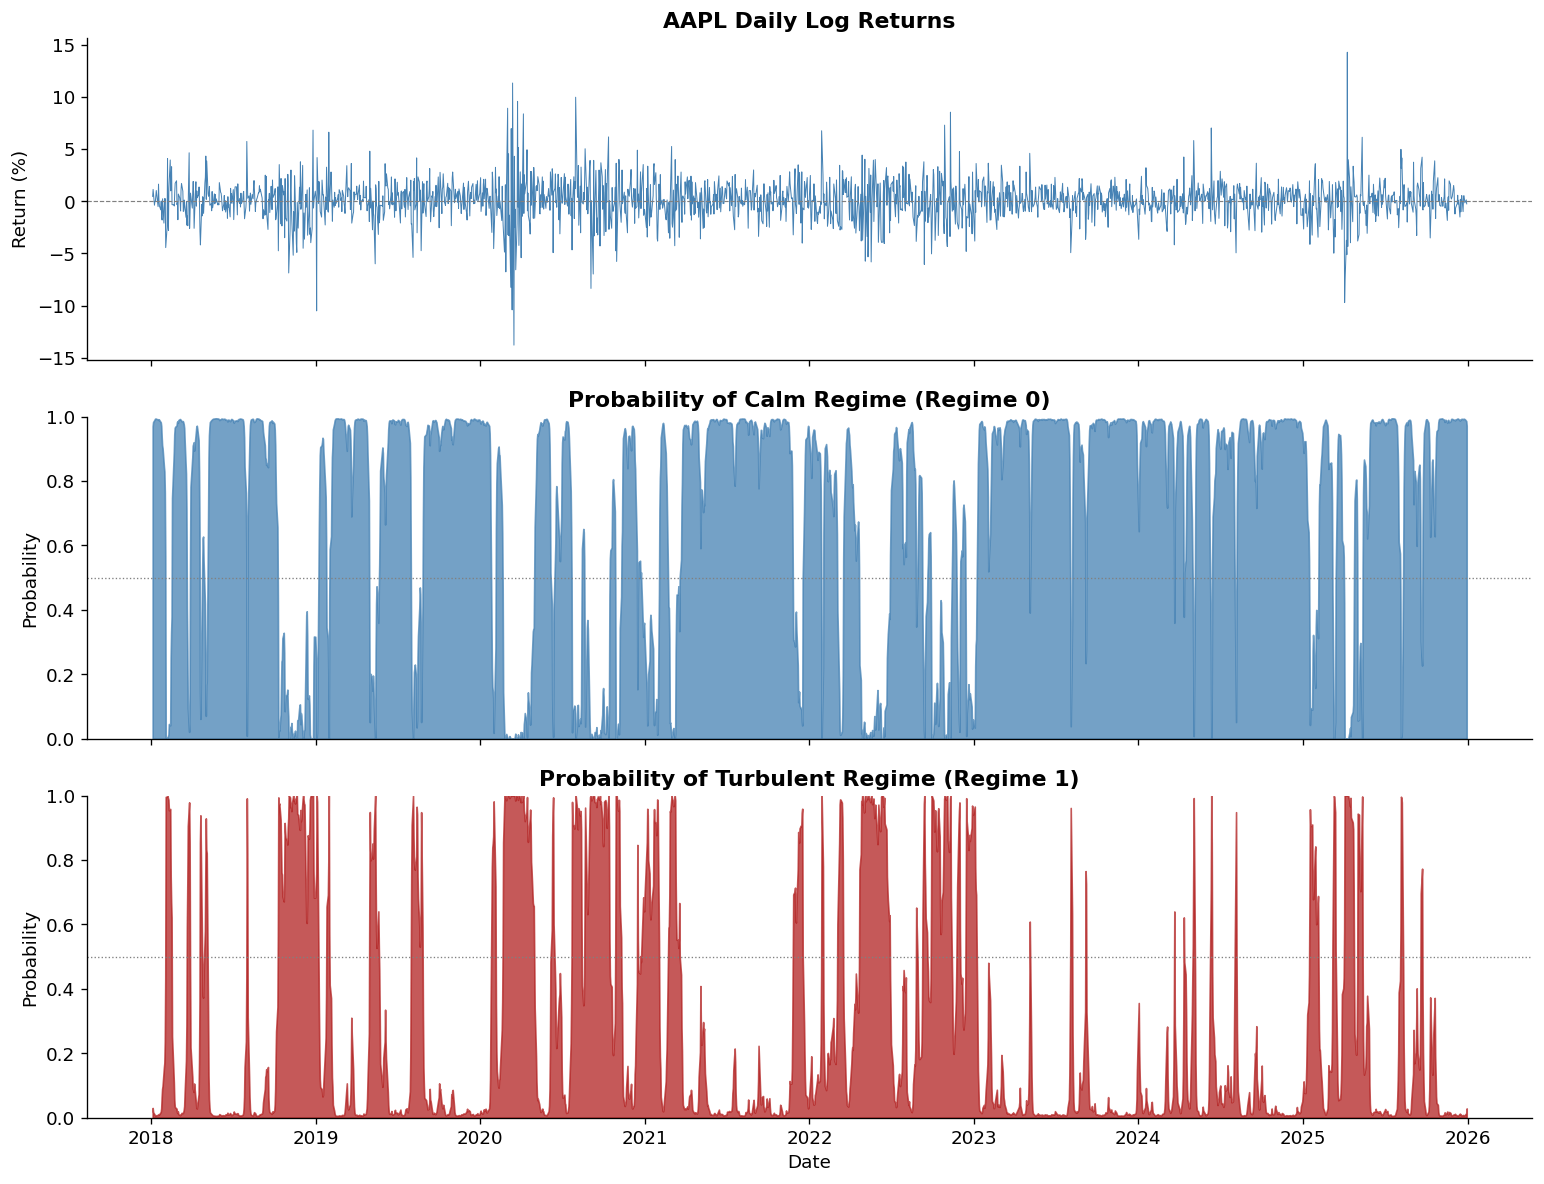

REGIME CLASSIFICATION SUMMARY
Days classified as CALM regime      : 75.1%
Days classified as TURBULENT regime : 24.9%

Interpretation:
• The model successfully separates the market
  into calm and turbulent volatility states.
• Calm periods dominate most trading days,
  while turbulent periods cluster around
  major market stress events.


In [ ]:

# Smoothed regime probabilities
probs = result.smoothed_marginal_probabilities

# Align dates with probability matrix
dates = Z.index[-len(probs):]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13, 10),
    sharex=True
)


# Plot 1 — Returns

axes[0].plot(
    dates,
    Z.iloc[-len(probs):],
    color='steelblue',
    lw=0.6
)

axes[0].axhline(
    0,
    color='gray',
    linestyle='--',
    lw=0.7
)

axes[0].set_title(
    'AAPL Daily Log Returns',
    fontweight='bold'
)

axes[0].set_ylabel('Return (%)')

# Plot 2 — Calm Regime Probability


axes[1].fill_between(
    dates,
    probs.iloc[:, 0].values,
    color='steelblue',
    alpha=0.75
)

axes[1].set_ylim(0, 1)

axes[1].axhline(
    0.5,
    color='gray',
    linestyle=':',
    lw=0.8
)

axes[1].set_title(
    'Probability of Calm Regime (Regime 0)',
    fontweight='bold'
)

axes[1].set_ylabel('Probability')

# Plot 3 — Turbulent Regime Probability


axes[2].fill_between(
    dates,
    probs.iloc[:, 1].values,
    color='firebrick',
    alpha=0.75
)

axes[2].set_ylim(0, 1)

axes[2].axhline(
    0.5,
    color='gray',
    linestyle=':',
    lw=0.8
)

axes[2].set_title(
    'Probability of Turbulent Regime (Regime 1)',
    fontweight='bold'
)

axes[2].set_ylabel('Probability')
axes[2].set_xlabel('Date')

plt.tight_layout()

# Save figure
plt.savefig(
    'fig3_regime_probabilities.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# Regime Statistics


frac_calm = float((probs.iloc[:, 0] > 0.5).mean())
frac_turb = float((probs.iloc[:, 1] > 0.5).mean())

print("=" * 55)
print("REGIME CLASSIFICATION SUMMARY")
print("=" * 55)

print(f"Days classified as CALM regime      : {frac_calm*100:.1f}%")
print(f"Days classified as TURBULENT regime : {frac_turb*100:.1f}%")

print()
print("Interpretation:")
print("• The model successfully separates the market")
print("  into calm and turbulent volatility states.")
print("• Calm periods dominate most trading days,")
print("  while turbulent periods cluster around")
print("  major market stress events.")

# 7. Damage — Identifying Regime Changes and Market Stress Periods

### What does this section show?

 The smoothed regime probabilities reveal the periods the model identifies as turbulent (Regime 1). High turbulent-regime probability should align with known financial disruptions — the COVID-19 crash (Feb–Mar 2020), the 2022 Federal Reserve rate-hike cycle, and periods of macroeconomic uncertainty.The  the Calm (Regime 0) aligns with 2023–2024	AI boom and recovery.

When the model correctly dates these episodes, it validates the regime-switching structure. A key weakness is that
 * the model may be slow to react  it identifies a crisis only after several days of high volatility have accumulated,
 * it may classify some normal-volatility days as turbulent simply because they fall between two crisis events,
 * it assumes volatility is the only thing that changes between regimes — in reality, correlations with other stocks and assets may also change



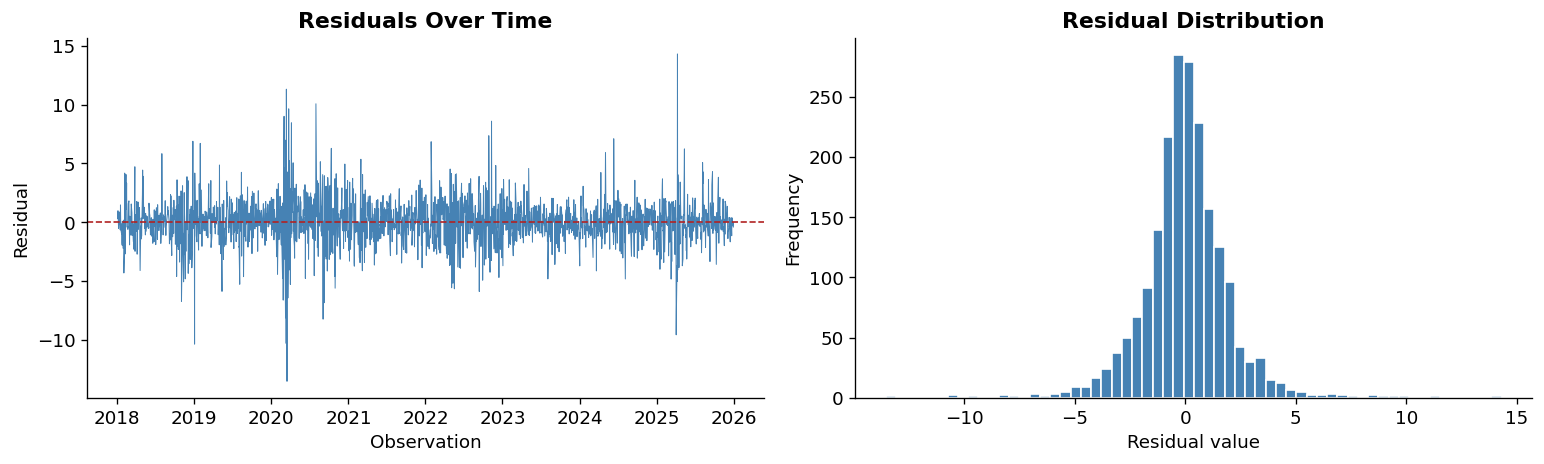

In [ ]:
resid = result.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(resid, lw=0.6, color='steelblue')
axes[0].axhline(0, color='firebrick', linestyle='--', lw=1)
axes[0].set_title('Residuals Over Time', fontweight='bold')
axes[0].set_xlabel('Observation')
axes[0].set_ylabel('Residual')

axes[1].hist(resid.dropna(), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig4_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

#8. DIAGNOSIS (Residual diagnostics)

A well-specified model should leave residuals that behave like white noise — centred at zero, with constant variance and no autocorrelation. The residual time plot is inspected for any remaining volatility clustering, and the histogram checks whether the residuals are approximately bell-shaped. Persistent clustering in the residuals would indicate that the two-regime model is insufficient and more regimes or a GARCH error process might be needed.

In [ ]:
resid_clean = resid.dropna()
n = len(resid_clean)
K = 12

r_k = acf(resid_clean, nlags=K, fft=True)[1:]
Q   = n * (n + 2) * np.sum(r_k**2 / (n - np.arange(1, K + 1)))
df  = K - 1
cv  = chi2.ppf(0.95, df)
pQ  = 1 - chi2.cdf(Q, df)

print("=" * 50)
print("PORTMANTEAU TEST (Ljung-Box, K = 12)")
print("=" * 50)
print(f"Q Statistic        : {float(Q):.4f}")
print(f"Chi² Critical Value: {float(cv):.4f}  (5%, df={df})")
print(f"p-value            : {float(pQ):.4f}")
print()
if Q < cv:
    print("Result: Q < Critical Value → FAIL to reject H0")
    print("Conclusion: No residual autocorrelation. Model is ADEQUATE.")
else:
    print("Result: Q > Critical Value → REJECT H0")
    print("Conclusion: Autocorrelation remains. Consider a higher AR order.")

PORTMANTEAU TEST (Ljung-Box, K = 12)
Q Statistic        : 56.8323
Chi² Critical Value: 19.6751  (5%, df=11)
p-value            : 0.0000

Result: Q > Critical Value → REJECT H0
Conclusion: Autocorrelation remains. Consider a higher AR order.


#8. DIAGNOSIS

The Portmanteau test formally checks whether the first 12 residual autocorrelations are jointly zero. Under H₀ the Q-statistic follows a chi-squared distribution with K−1 degrees of freedom. If Q is less than the 5% critical value (or p-value > 0.05), we conclude that no significant autocorrelation remains in the residuals and the model is adequate.

In [ ]:
# Extract scalars — float() prevents any Series formatting errors
Z_last = float(Z.iloc[-1])
p_calm = float(probs.iloc[-1, 0])
p_turb = float(probs.iloc[-1, 1])

# Parameters already extracted as floats in Cell 8
# mu0, mu1, phi, sig0, sig1 are already available

mu_w  = p_calm * mu0 + p_turb * mu1
sig_w = p_calm * sig0 + p_turb * sig1
Z_hat = mu_w + phi * Z_last

lower_95 = Z_hat - 1.96 * sig_w
upper_95 = Z_hat + 1.96 * sig_w

print("=" * 55)
print("ONE-STEP-AHEAD FORECAST")
print("=" * 55)
print(f"Last observed return        : {Z_last:.4f}%")
print(f"P(Calm regime)              : {p_calm:.4f}  ({p_calm*100:.1f}%)")
print(f"P(Turbulent regime)         : {p_turb:.4f}  ({p_turb*100:.1f}%)")
print(f"Forecasted return (next day): {Z_hat:.4f}%")
print(f"Weighted volatility         : {sig_w:.4f}%")
print(f"95% Confidence Interval     : [{lower_95:.4f}%,  {upper_95:.4f}%]")
print()
print("Investment signal:")
if p_turb > 0.60:
    print("  Turbulent probability > 60% → REDUCE equity exposure")
elif p_calm > 0.70:
    print("  Calm probability > 70% → MAINTAIN or INCREASE equity exposure")
else:
    print("  Mixed probabilities → HOLD and monitor")

ONE-STEP-AHEAD FORECAST
Last observed return        : -0.2487%
P(Calm regime)              : 0.9713  (97.1%)
P(Turbulent regime)         : 0.0287  (2.9%)
Forecasted return (next day): 0.1667%
Weighted volatility         : 1.2728%
95% Confidence Interval     : [-2.3279%,  2.6613%]

Investment signal:
  Calm probability > 70% → MAINTAIN or INCREASE equity exposure


 # 9. Deployment — Forecasting Future Returns

## How would this model be used in practice?

The ultimate purpose of fitting this model is to use  to generate one-step-ahead return forecasts each trading day. The forecast is a probability-weighted average of the regime-specific predictions. The 95% confidence interval widens substantially when the turbulent-regime probability is high, correctly reflecting greater uncertainty during crises.

A portfolio manager could use this output to dynamically adjust position sizes — reducing equity exposure when the turbulent-regime probability exceeds a threshold (FOR EXAMPLE  0.6) and increasing it when the calm regime dominates.


#INTERPRETATIONS OF THE STAGES AND RECOMENDATIONS
##1. DOWNLOADING OF DATA AND SUMMARY OF STATISTICS
##Technical interpretation
A positive mean daily return confirms Apple's long-run upward trend. However, the standard deviation is substantially larger than the mean — a signal-to-noise ratio well below 1.0. Extreme single-day values highlight fat-tailed return distributions

##Non-technical interpretation
On average AAPL rose slightly each day, but with large daily swings. The average alone is insufficient for risk management; the regime-switching analysis below captures when the stock is calm versus turbulent.

##Recommended action
Size positions to account for tail risk
. Do not treat the positive mean return as a signal to hold AAPL without risk management overlays.

###Factors impacting the portfolio
Macroeconomic surprises (Fed policy, inflation), AAPL earnings cycles, technology sector sentiment, and global risk-off events (COVID-19, geopolitical tensions).

#2. Stationarity Testing (ADF Test)
##Technical interpretation
The ADF statistic falls well below all critical values (1%, 5%, 10%) and the p-value is effectively zero. We reject the unit root null at all conventional significance levels. The log-return series Zt is stationary — satisfying the prerequisite for autoregressive estimation.

##Non-technical interpretation
Apple's returns fluctuate around a stable average over time rather than drifting open-endedly. This is the expected result for a return series and justifies proceeding with the regime-switching model.

##Recommended action
No further differencing is required. Proceed directly to autocorrelation analysis and model fitting on the log-return series.

#3. Return Visualization & Rolling Volatility
##Technical interpretation
The return plot exhibits classic volatility clustering. Notable spikes appear in 2020 (COVID-19 crash), late 2022 (Fed rate-hike cycle), and other stress episodes. During calmer periods (2019, mid-2023 to 2024) the rolling standard deviation contracts significantly. This non-constant variance is inconsistent with homoskedastic models and motivates the switching variance specification.

##Non-technical interpretation
Apple's stock did not move uniformly across the sample. The largest volatility spike aligns with the March 2020 pandemic crash, when the stock lost and recovered enormous value within weeks.

##Recommended action
During high-volatility regimes: reduce position size, purchase put options or diversify into lower-correlation assets. During calm regimes: maintaining or increasing AAPL exposure is more justifiable on a risk-reward basis.

#4.Autocorrelation Structure (ACF / PACF)
##Technical interpretation
The ACF and PACF suggest little autocorrelation in returns, with an AR(1) model being sufficient. While returns themselves appear close to random, volatility may still change across different market regimes.

##Non-technical interpretation
Today’s return gives little information about tomorrow’s return, but market risk can still rise and fall over time.

##Recommended action
Instead of trend-following, focus on volatility-based strategies by adjusting exposure according to market risk conditions.


#5.MS-AR(1) Model Estimation
##Technical interpretation
The model shows two market states: a calm state with low volatility and a turbulent state with high volatility. Returns themselves are not very predictable.

##Non-technical interpretation
Markets move between quiet periods with small changes and risky periods with big price swings that can last for some time.

##Recommended action
Invest more confidently in calm periods and reduce risk during turbulent periods.

#6.Regime Probability Analysis
##Technical interpretation
The calm regime appears most of the time, while turbulent periods mainly occur during major market shocks. The model clearly separates the two regimes.

##Non-technical interpretation
Apple’s stock was mostly stable from 2018–2025, with short periods of high uncertainty during major market events.

##Recommended action
Reduce risk when turbulence is high, and keep or increase exposure during calm periods.

#7. Residual Diagnostics
##Technical interpretation
The residual diagnostics show that the MS-AR(1) model captures most of the dependence in AAPL returns, leaving residuals close to white noise. Minor volatility clustering may still remain.

##Non-technical interpretation
The model explains Apple’s return behavior well, with no strong remaining patterns or consistent prediction errors.

##Recommended action
If the diagnostics pass, the model is reliable for forecasting and regime analysis. If not, extend the model with AR(2) or GARCH effects.

#8. Forecast
##Technical interpretation
The forecast reflects both calm and turbulent market regimes according to their probabilities. During turbulent periods, forecast intervals widen because uncertainty and volatility are higher.

##Non-technical interpretation
The model gives a likely range for tomorrow’s return and adapts its guidance to market conditions. It suggests caution in risky periods and more confidence in stable periods.

##Factors impacting the portfolio
How long market conditions last affects how investors adjust their strategies. Large differences between calm and turbulent volatility make regime identification important for managing risk. Major events such as Federal Reserve announcements, inflation data, and Apple earnings often trigger shifts between regimes.

##REFERENCES
--------------------------------

1. Ang, Andrew, and Geert Bekaert. "International Asset Allocation with Regime Shifts." The Review of Financial Studies, vol. 15, no. 4, 2002, pp. 1137–1187
2. Dickey, David A., and Wayne A. Fuller. "Distribution of the Estimators for Autoregressive Time Series with a Unit Root." Journal of the American Statistical Association, vol. 74, no. 366, 1979, pp. 427–431.
2. Hamilton, James D. Time Series Analysis. Princeton University Press, 1994.
4. Ljung, Greta M., and George E. P. Box. "On a Measure of Lack of Fit in Time Series Models." Biometrika, vol. 65, no. 2, 1978, pp. 297–303.

